# Multiple Testing Correction for A/B Experiments

When an experiment tests **multiple metrics** (primary, secondary,
guardrail), the probability of at least one false positive inflates
rapidly.  This notebook demonstrates the problem and three solutions.

**Sections:**
1. The Multiple Comparisons Problem
2. Correction Methods (Bonferroni, Holm, FDR)
3. Method Comparison on Real Data
4. Hierarchical (Gate-Keeping) Strategy
5. Experiment 1 — Full Hierarchical Analysis
6. All 10 Experiments
7. Cross-Experiment Correction
8. Best Practices & Recommendations

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

ROOT = Path.cwd() if "notebooks" not in str(Path.cwd()) else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ecommerce_analytics.analysis import (
    ExperimentCatalog,
    MultiMetricAnalyzer,
    compare_corrections,
    load_experiment_data,
    simulate_fwer,
)
from ecommerce_analytics.analysis.multiple_testing import STANDARD_METRICS

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.float_format", "{:.4f}".format)

ALPHA = 0.05
catalog = ExperimentCatalog()

---
## 1. The Multiple Comparisons Problem

If each test has a 5 % false-positive rate and you run *k* independent
tests, the probability of **at least one** false positive is:

$$\text{FWER} = 1 - (1 - \alpha)^k$$

| Tests (k) | FWER |
|---|---|
| 1 | 5.0 % |
| 3 | 14.3 % |
| 5 | 22.6 % |
| 10 | 40.1 % |
| 20 | 64.2 % |

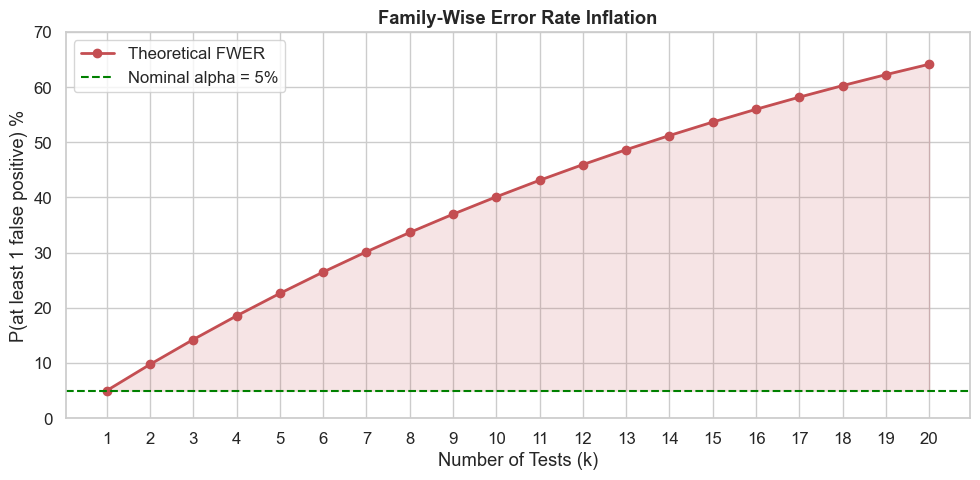

With 5 metrics per experiment: FWER = 22.6%
With 10 experiments x 5 metrics = 50 tests: FWER = 92.3%


In [2]:
ks = np.arange(1, 21)
fwer_theoretical = 1 - (1 - ALPHA) ** ks

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ks, fwer_theoretical * 100, "o-", linewidth=2, color="#c44e52",
        markersize=6, label="Theoretical FWER")
ax.axhline(5, color="green", linestyle="--", linewidth=1.5,
           label="Nominal alpha = 5%")
ax.fill_between(ks, 5, fwer_theoretical * 100, alpha=0.15, color="#c44e52")
ax.set_xlabel("Number of Tests (k)")
ax.set_ylabel("P(at least 1 false positive) %")
ax.set_title("Family-Wise Error Rate Inflation", fontweight="bold")
ax.legend()
ax.set_xticks(ks)
ax.set_ylim(0, 70)
plt.tight_layout()
plt.show()

print(f"With 5 metrics per experiment: FWER = {1-(1-ALPHA)**5:.1%}")
print(f"With 10 experiments x 5 metrics = 50 tests: FWER = {1-(1-ALPHA)**50:.1%}")

In [3]:
# Monte Carlo simulation to confirm theoretical FWER
sim = simulate_fwer(n_tests=5, alpha=ALPHA, n_simulations=50_000)

print("FWER simulation (5 tests, global null — no real effects):")
print(f"  Theoretical              : {sim['theoretical_fwer']:.1%}")
print(f"  Simulated (no correction): {sim['simulated_fwer_none']:.1%}")
print(f"  Simulated (Bonferroni)   : {sim['simulated_fwer_bonferroni']:.1%}")
print(f"  Simulated (FDR-BH)       : {sim['simulated_fwer_fdr']:.1%}")
print()
print("Without correction, ~23% of experiments will have a spurious")
print("'significant' metric even when there is no real effect.")

FWER simulation (5 tests, global null — no real effects):
  Theoretical              : 22.6%
  Simulated (no correction): 22.5%
  Simulated (Bonferroni)   : 5.0%
  Simulated (FDR-BH)       : 5.1%

Without correction, ~23% of experiments will have a spurious
'significant' metric even when there is no real effect.


---
## 2. Correction Methods

### Bonferroni
Reject if $p_i < \alpha / k$.  Controls FWER exactly but is conservative
(reduces power).

### Holm (step-down Bonferroni)
Sort p-values ascending.  Reject $p_{(i)}$ if $p_{(i)} < \alpha / (k - i + 1)$.
Uniformly more powerful than Bonferroni while still controlling FWER.

### Benjamini-Hochberg (FDR)
Controls the *expected fraction of false discoveries* rather than FWER.
More powerful; preferred when k is large.

In [4]:
# Worked example with synthetic p-values
example_metrics = ["conversion_rate", "aov", "items_per_order",
                   "revenue_per_user", "profit_margin"]
example_pvals = [0.001, 0.015, 0.042, 0.078, 0.031]

comp = compare_corrections(example_pvals, example_metrics, alpha=ALPHA)
pivot = comp.pivot(index="metric", columns="method",
                   values=["corrected_p", "significant"])

# Flatten column names
display_df = pd.DataFrame({
    "metric": example_metrics,
    "raw_p": example_pvals,
})
for method in ["none", "bonferroni", "holm", "fdr_bh"]:
    sub = comp[comp["method"] == method].set_index("metric")
    display_df[f"{method}_p"] = display_df["metric"].map(sub["corrected_p"])
    display_df[f"{method}_sig"] = display_df["metric"].map(sub["significant"])

display_df

,metric,raw_p,none_p,none_sig,bonferroni_p,bonferroni_sig,holm_p,holm_sig,fdr_bh_p,fdr_bh_sig
0,conversion_rate,0.0010,0.0010,True,0.0050,True,0.0050,True,0.0050,True
1,aov,0.0150,0.0150,True,0.0750,False,0.0600,False,0.0375,True
2,items_per_order,0.0420,0.0420,True,0.2100,False,0.0930,False,0.0525,False
3,revenue_per_user,0.0780,0.0780,False,0.3900,False,0.0930,False,0.0780,False
4,profit_margin,0.0310,0.0310,True,0.1550,False,0.0930,False,0.0517,False


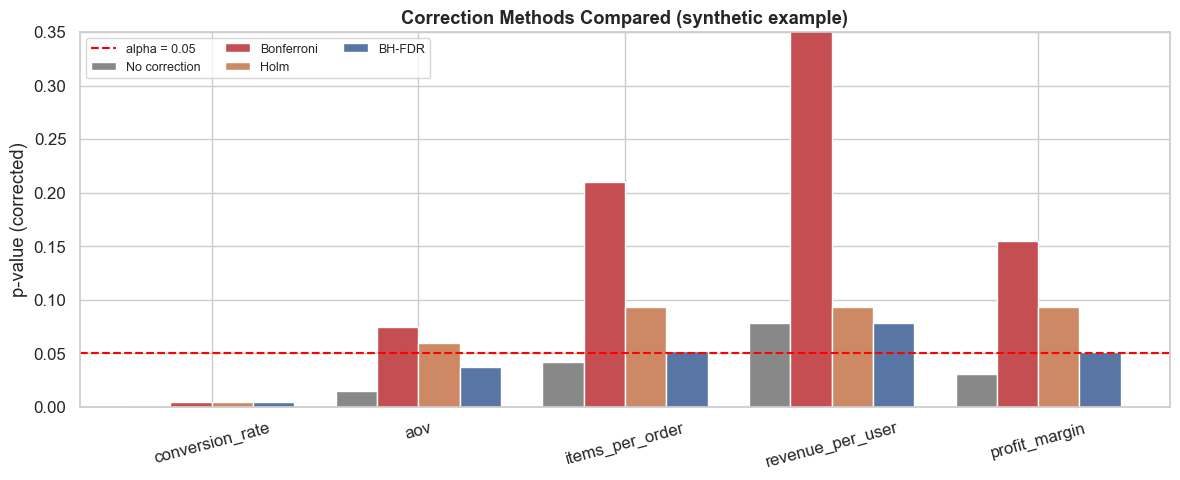

Observations:
  - Bonferroni is the most conservative (fewest rejections)
  - Holm is uniformly more powerful than Bonferroni
  - FDR-BH is the most liberal (most rejections)
  - All three correctly reject conversion_rate (p=0.001)


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(example_metrics))
w = 0.2
methods = ["none", "bonferroni", "holm", "fdr_bh"]
labels = ["No correction", "Bonferroni", "Holm", "BH-FDR"]
colors = ["#888888", "#c44e52", "#cc8963", "#5975a4"]

for j, (method, label, color) in enumerate(zip(methods, labels, colors)):
    vals = display_df[f"{method}_p"].values
    # Cap at 1 for display
    vals = np.minimum(vals, 1.0)
    ax.bar(x + j * w, vals, w, label=label, color=color, edgecolor="white")

ax.axhline(ALPHA, color="red", linestyle="--", linewidth=1.5,
           label=f"alpha = {ALPHA}")
ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(example_metrics, rotation=15)
ax.set_ylabel("p-value (corrected)")
ax.set_title("Correction Methods Compared (synthetic example)", fontweight="bold")
ax.legend(fontsize=9, ncol=3)
ax.set_ylim(0, 0.35)
plt.tight_layout()
plt.show()

print("Observations:")
print("  - Bonferroni is the most conservative (fewest rejections)")
print("  - Holm is uniformly more powerful than Bonferroni")
print("  - FDR-BH is the most liberal (most rejections)")
print("  - All three correctly reject conversion_rate (p=0.001)")

---
## 3. Correction Methods on Real Experiment Data

Apply all methods to Experiment 1 (Free Shipping Threshold) with
5 metrics: conversion rate, AOV, items/order, revenue/user, review score.

In [6]:
data_001 = load_experiment_data("exp_001")

mma = MultiMetricAnalyzer(data_001, metrics=STANDARD_METRICS, alpha=ALPHA)
raw_results = mma.run_all()

print("Raw (uncorrected) results for exp_001:")
raw_results

Raw (uncorrected) results for exp_001:


,metric,role,type,control,treatment,absolute_diff,relative_diff_%,statistic,p_value
0,conversion_rate,primary,proportion,0.1201,0.1345,0.0144,11.9500,-6.7896,0.0000
1,aov,secondary,continuous,140.7554,138.8264,-1.9290,-1.3700,19820811.5000,0.4569
2,items_per_order,secondary,continuous,1.1376,1.1345,-0.0032,-0.2800,20012526.0000,0.7230
3,revenue_per_user,secondary,continuous,16.9109,18.6718,1.7609,10.4100,1218425828.0000,0.0000
4,review_score,guardrail,continuous,4.0820,4.0925,0.0105,0.2600,19615962.0000,0.5774


In [7]:
real_pvals = raw_results["p_value"].tolist()
real_names = raw_results["metric"].tolist()

real_comp = compare_corrections(real_pvals, real_names, alpha=ALPHA)

# Pivot for display
real_display = pd.DataFrame({"metric": real_names, "raw_p": real_pvals})
for method in ["none", "bonferroni", "holm", "fdr_bh"]:
    sub = real_comp[real_comp["method"] == method].set_index("metric")
    real_display[f"{method}_sig"] = real_display["metric"].map(sub["significant"])

real_display

,metric,raw_p,none_sig,bonferroni_sig,holm_sig,fdr_bh_sig
0,conversion_rate,0.0000,True,True,True,True
1,aov,0.4569,False,False,False,False
2,items_per_order,0.7230,False,False,False,False
3,revenue_per_user,0.0000,True,True,True,True
4,review_score,0.5774,False,False,False,False


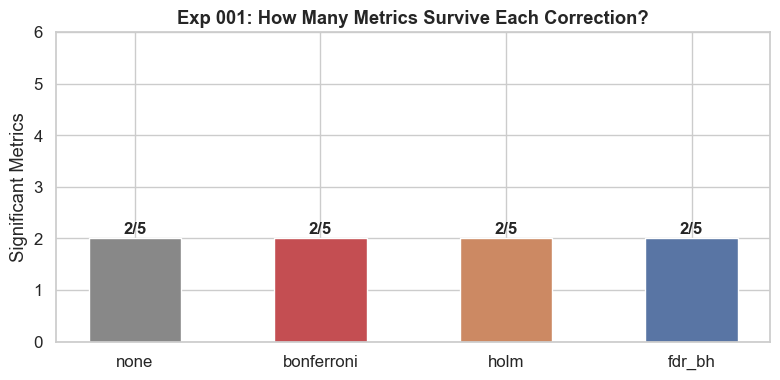

In [8]:
# Count significant metrics per method
sig_counts = {}
for method in ["none", "bonferroni", "holm", "fdr_bh"]:
    sig_counts[method] = int(real_display[f"{method}_sig"].sum())

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(list(sig_counts.keys()), list(sig_counts.values()),
              color=["#888888", "#c44e52", "#cc8963", "#5975a4"],
              edgecolor="white", width=0.5)
for bar, val in zip(bars, sig_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val}/5", ha="center", fontweight="bold", fontsize=12)
ax.set_ylabel("Significant Metrics")
ax.set_title("Exp 001: How Many Metrics Survive Each Correction?", fontweight="bold")
ax.set_ylim(0, 6)
plt.tight_layout()
plt.show()

---
## 4. Hierarchical (Gate-Keeping) Strategy

The hierarchical approach avoids the power loss of blanket correction:

```
Step 1: Test PRIMARY metric (no correction)
   |-- Not significant --> STOP, experiment failed
   |-- Significant --> proceed to Step 2
        |
Step 2: Test SECONDARY metrics (with Holm correction)
        |
Step 3: Test GUARDRAIL metrics (always, one-sided, no correction)
   |-- Guardrail triggered --> BLOCK launch
   |-- Guardrails OK --> LAUNCH
```

**Why this works:**
- Primary metric has full alpha (no power loss for the most important test)
- Secondary metrics are only tested conditionally, so the gate controls
  overall error rate without formal correction on the primary
- Guardrails are a *separate question* (safety, not efficacy) so they
  don't belong in the same family of tests

In [9]:
ht = mma.hierarchical_test()

print("=" * 65)
print("  HIERARCHICAL TESTING — Experiment 1")
print("=" * 65)

print("\nStep 1: PRIMARY METRIC (no correction)")
print(ht["primary"][["metric", "control", "treatment",
                       "relative_diff_%", "p_value", "significant"]].to_string(index=False))
print(f"  Gate passed: {ht['primary_passed']}")

print(f"\nStep 2: SECONDARY METRICS ({ht['correction_method']} correction)")
sec_cols = ["metric", "control", "treatment", "relative_diff_%",
            "p_value", "corrected_p", "significant", "note"]
print(ht["secondary"][sec_cols].to_string(index=False))

print("\nStep 3: GUARDRAIL METRICS (always tested, one-sided)")
print(ht["guardrail"][["metric", "control", "treatment",
                        "absolute_diff", "p_value", "significant",
                        "triggered"]].to_string(index=False))
print(f"  Guardrails OK: {ht['guardrail_ok']}")

print(f"\n{'=' * 65}")
print(f"  DECISION: {ht['decision']}")
print(f"  {ht['reasoning']}")
print(f"{'=' * 65}")

  HIERARCHICAL TESTING — Experiment 1

Step 1: PRIMARY METRIC (no correction)
         metric  control  treatment  relative_diff_%  p_value  significant
conversion_rate   0.1201     0.1345          11.9500   0.0000         True
  Gate passed: True

Step 2: SECONDARY METRICS (holm correction)
          metric  control  treatment  relative_diff_%  p_value  corrected_p  significant                         note
             aov 140.7554   138.8264          -1.3700   0.4569       0.9138        False tested (primary passed gate)
 items_per_order   1.1376     1.1345          -0.2800   0.7230       0.9138        False tested (primary passed gate)
revenue_per_user  16.9109    18.6718          10.4100   0.0000       0.0000         True tested (primary passed gate)

Step 3: GUARDRAIL METRICS (always tested, one-sided)
      metric  control  treatment  absolute_diff  p_value  significant  triggered
review_score   4.0820     4.0925         0.0105   0.5774        False      False
  Guardrails OK: Tr

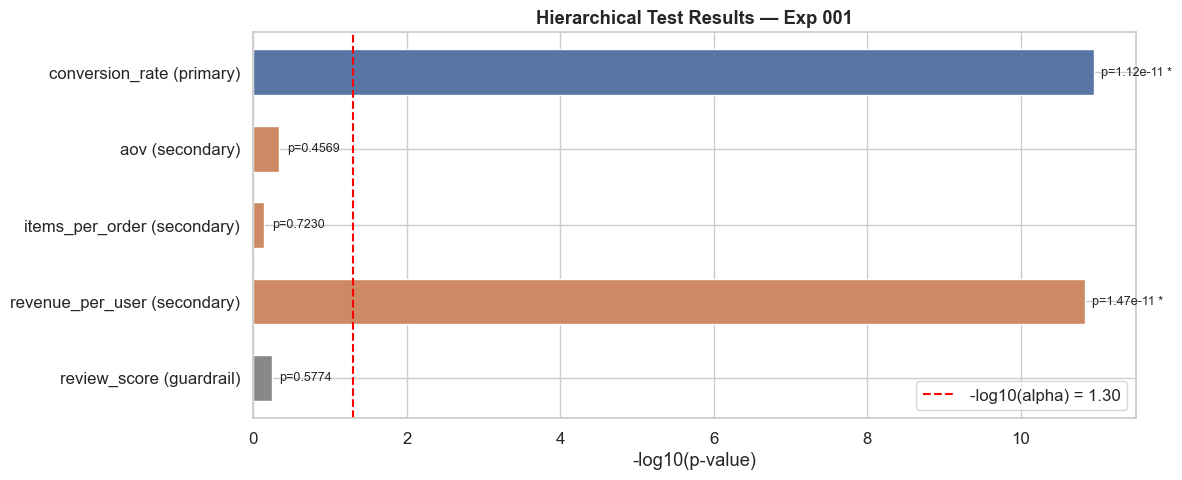

In [10]:
# Visualise the hierarchical flow
all_res = ht["all_results"].copy()

fig, ax = plt.subplots(figsize=(12, 5))
y = np.arange(len(all_res))

role_colors = {"primary": "#5975a4", "secondary": "#cc8963", "guardrail": "#888888"}
bar_colors = [role_colors[r] for r in all_res["role"]]
sig_markers = ["*" if s else "" for s in all_res["significant"]]

bars = ax.barh(y, -np.log10(all_res["p_value"].clip(1e-20)),
               color=bar_colors, height=0.6, edgecolor="white")
ax.axvline(-np.log10(ALPHA), color="red", linestyle="--",
           label=f"-log10(alpha) = {-np.log10(ALPHA):.2f}")

for i, (bar, sig, p) in enumerate(zip(bars, all_res["significant"], all_res["p_value"])):
    label = f"p={p:.2e}" if p < 0.01 else f"p={p:.4f}"
    if sig:
        label += " *"
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels([f"{r['metric']} ({r['role']})" for _, r in all_res.iterrows()])
ax.set_xlabel("-log10(p-value)")
ax.set_title("Hierarchical Test Results — Exp 001", fontweight="bold")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 5. Detailed Walk-Through — Experiment 1

Let's trace the numbers step by step.

In [11]:
print("Pre-specified metric hierarchy (documented BEFORE experiment):")
print()
for spec in STANDARD_METRICS:
    print(f"  [{spec.role.upper():10s}] {spec.name:25s}  type={spec.metric_type}")
print()
print("Rules:")
print("  1. Primary tested at alpha = 0.05 (no correction)")
print("  2. Secondary tested only if primary passes (Holm correction)")
print("  3. Guardrails tested always (one-sided: is treatment WORSE?)")

Pre-specified metric hierarchy (documented BEFORE experiment):

  [PRIMARY   ] conversion_rate            type=proportion
  [SECONDARY ] aov                        type=continuous
  [SECONDARY ] items_per_order            type=continuous
  [SECONDARY ] revenue_per_user           type=continuous
  [GUARDRAIL ] review_score               type=continuous

Rules:
  1. Primary tested at alpha = 0.05 (no correction)
  2. Secondary tested only if primary passes (Holm correction)
  3. Guardrails tested always (one-sided: is treatment WORSE?)


In [12]:
# Show what happens with vs without correction
print("Effect of correction on Experiment 1 secondary metrics:")
print()
sec = ht["secondary"]
for _, row in sec.iterrows():
    raw_sig = row["p_value"] < ALPHA
    cor_sig = row["significant"]
    status = "unchanged" if raw_sig == cor_sig else "FLIPPED"
    print(f"  {row['metric']:20s}  raw_p={row['p_value']:.4f} ({'sig' if raw_sig else 'ns':>3s}) "
          f" --> corrected_p={row['corrected_p']:.4f} ({'sig' if cor_sig else 'ns':>3s})  [{status}]")

print(f"\nCorrection method: {ht['correction_method']}")
print(f"Without correction, {int(sec['p_value'].lt(ALPHA).sum())} secondary metrics significant.")
print(f"After correction,   {int(sec['significant'].sum())} secondary metrics significant.")

Effect of correction on Experiment 1 secondary metrics:

  aov                   raw_p=0.4569 ( ns)  --> corrected_p=0.9138 ( ns)  [unchanged]
  items_per_order       raw_p=0.7230 ( ns)  --> corrected_p=0.9138 ( ns)  [unchanged]
  revenue_per_user      raw_p=0.0000 (sig)  --> corrected_p=0.0000 (sig)  [unchanged]

Correction method: holm
Without correction, 1 secondary metrics significant.
After correction,   1 secondary metrics significant.


---
## 6. All 10 Experiments — Hierarchical Analysis

In [13]:
all_experiments = []

for exp_id in catalog.list_ids():
    try:
        exp_data = load_experiment_data(exp_id)
        exp_meta = catalog.get(exp_id)
        mma_exp = MultiMetricAnalyzer(exp_data, alpha=ALPHA, correction="holm")
        ht_exp = mma_exp.hierarchical_test()

        primary_p = float(ht_exp["primary"]["p_value"].iloc[0])
        primary_lift = float(ht_exp["primary"]["relative_diff_%"].iloc[0])
        n_sec_sig = int(ht_exp["secondary"]["significant"].sum())
        n_sec = len(ht_exp["secondary"])

        all_experiments.append({
            "experiment": exp_meta.name,
            "primary_p": primary_p,
            "primary_lift_%": primary_lift,
            "primary_sig": ht_exp["primary_passed"],
            "secondary_sig": f"{n_sec_sig}/{n_sec}",
            "guardrail_ok": ht_exp["guardrail_ok"],
            "decision": ht_exp["decision"],
        })
    except Exception as e:
        print(f"  {exp_id} skipped: {e}")

all_exp_df = pd.DataFrame(all_experiments)
all_exp_df

,experiment,primary_p,primary_lift_%,primary_sig,secondary_sig,guardrail_ok,decision
0,Free Shipping Threshold,0.0000,11.9500,True,1/3,True,STRONG LAUNCH
1,Payment Installments (6 vs 12 months),0.0000,15.1600,True,1/3,True,STRONG LAUNCH
2,One-Page Checkout,0.0001,5.9400,True,1/3,True,STRONG LAUNCH
3,Review Solicitation Timing (3d vs 7d),0.0000,19.8400,True,1/3,True,STRONG LAUNCH
4,Product Recommendations (Personalized vs Popular),0.0000,12.7100,True,1/3,True,STRONG LAUNCH
5,Delivery Speed Options (Standard vs Express),0.0000,7.3100,True,1/3,True,STRONG LAUNCH
6,Seller Ratings Display (Show vs Hide),0.0000,10.2700,True,1/3,True,STRONG LAUNCH
7,Bundle Discounts (3 items for 10% off),0.0000,16.7500,True,1/3,True,STRONG LAUNCH
8,Guest Checkout (Guest vs Forced Registration),0.0000,15.0800,True,1/3,True,STRONG LAUNCH
9,Dynamic Pricing (Demand-Based),0.0111,4.2000,True,1/3,True,STRONG LAUNCH


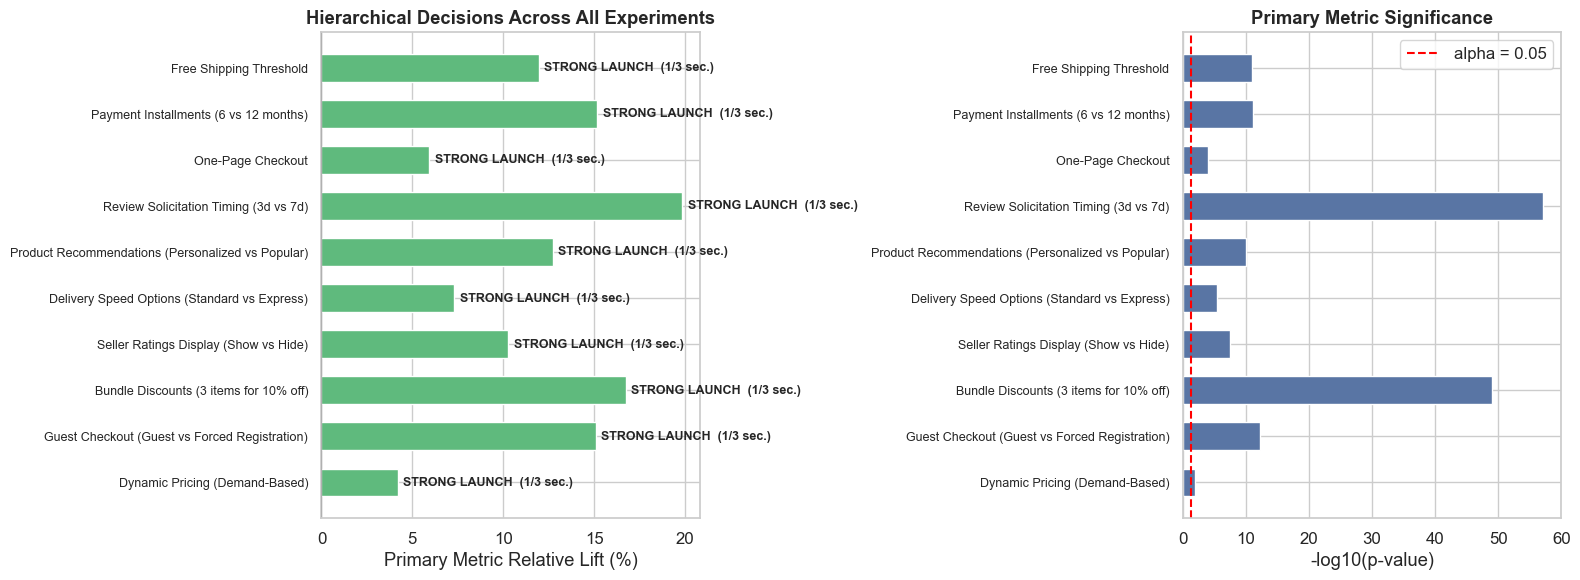

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── 6a  Decisions across experiments ───────────────────────────────
ax = axes[0]
decision_colors = {
    "STRONG LAUNCH": "#5fba7d",
    "LAUNCH": "#5975a4",
    "FAIL": "#c44e52",
    "BLOCKED": "#888888",
}
y = np.arange(len(all_exp_df))
bar_colors = [decision_colors.get(d, "#cccccc") for d in all_exp_df["decision"]]
ax.barh(y, all_exp_df["primary_lift_%"], color=bar_colors, height=0.6, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
for i, (_, row) in enumerate(all_exp_df.iterrows()):
    ax.text(row["primary_lift_%"] + 0.3, i,
            f"{row['decision']}  ({row['secondary_sig']} sec.)",
            va="center", fontsize=9, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(all_exp_df["experiment"], fontsize=9)
ax.set_xlabel("Primary Metric Relative Lift (%)")
ax.set_title("Hierarchical Decisions Across All Experiments", fontweight="bold")
ax.invert_yaxis()

# ── 6b  Primary p-values ──────────────────────────────────────────
ax = axes[1]
p_colors = ["#5975a4" if p < ALPHA else "#c44e52" for p in all_exp_df["primary_p"]]
ax.barh(y, -np.log10(all_exp_df["primary_p"].clip(1e-60)),
        color=p_colors, height=0.6, edgecolor="white")
ax.axvline(-np.log10(ALPHA), color="red", linestyle="--", label=f"alpha = {ALPHA}")
ax.set_yticks(y)
ax.set_yticklabels(all_exp_df["experiment"], fontsize=9)
ax.set_xlabel("-log10(p-value)")
ax.set_title("Primary Metric Significance", fontweight="bold")
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

---
## 7. Cross-Experiment Correction

When running 10 experiments simultaneously, we also face a
cross-experiment multiple testing problem.  Apply FDR correction to the
10 primary p-values.

In [15]:
primary_pvals = all_exp_df["primary_p"].tolist()
reject_bonf, corrected_bonf, _, _ = multipletests(primary_pvals, alpha=ALPHA, method="bonferroni")
reject_fdr, corrected_fdr, _, _ = multipletests(primary_pvals, alpha=ALPHA, method="fdr_bh")

cross_exp = pd.DataFrame({
    "experiment": all_exp_df["experiment"],
    "raw_p": primary_pvals,
    "raw_sig": [p < ALPHA for p in primary_pvals],
    "bonferroni_p": corrected_bonf,
    "bonferroni_sig": reject_bonf,
    "fdr_p": corrected_fdr,
    "fdr_sig": reject_fdr,
})
cross_exp

,experiment,raw_p,raw_sig,bonferroni_p,bonferroni_sig,fdr_p,fdr_sig
0,Free Shipping Threshold,0.0000,True,0.0000,True,0.0000,True
1,Payment Installments (6 vs 12 months),0.0000,True,0.0000,True,0.0000,True
2,One-Page Checkout,0.0001,True,0.0010,True,0.0001,True
3,Review Solicitation Timing (3d vs 7d),0.0000,True,0.0000,True,0.0000,True
4,Product Recommendations (Personalized vs Popular),0.0000,True,0.0000,True,0.0000,True
5,Delivery Speed Options (Standard vs Express),0.0000,True,0.0000,True,0.0000,True
6,Seller Ratings Display (Show vs Hide),0.0000,True,0.0000,True,0.0000,True
7,Bundle Discounts (3 items for 10% off),0.0000,True,0.0000,True,0.0000,True
8,Guest Checkout (Guest vs Forced Registration),0.0000,True,0.0000,True,0.0000,True
9,Dynamic Pricing (Demand-Based),0.0111,True,0.1114,False,0.0111,True


In [16]:
n_raw = int(cross_exp["raw_sig"].sum())
n_bonf = int(cross_exp["bonferroni_sig"].sum())
n_fdr = int(cross_exp["fdr_sig"].sum())

print(f"Cross-experiment correction (10 primary metrics):")
print(f"  No correction : {n_raw}/10 significant")
print(f"  Bonferroni    : {n_bonf}/10 significant")
print(f"  FDR (BH)      : {n_fdr}/10 significant")
print()
if n_raw == n_fdr:
    print("All experiments survive FDR correction — results are robust.")
else:
    lost = cross_exp[(cross_exp["raw_sig"]) & (~cross_exp["fdr_sig"])]["experiment"].tolist()
    print(f"Experiments losing significance after FDR: {lost}")

Cross-experiment correction (10 primary metrics):
  No correction : 10/10 significant
  Bonferroni    : 9/10 significant
  FDR (BH)      : 10/10 significant

All experiments survive FDR correction — results are robust.


---
## 8. Best Practices & Recommendations

### Pre-Registration Checklist

Before an experiment launches, document:

| Item | Example |
|---|---|
| Primary metric | Conversion rate |
| Secondary metrics | AOV, items/order, revenue/user |
| Guardrail metrics | Review score, profit margin |
| Alpha | 0.05 |
| Correction method for secondary | Holm |
| MDE and required sample size | 10%, 2,450/variant |
| Decision rules | Primary sig + guardrails OK = Launch |

### Method Selection Guide

| Scenario | Recommended |
|---|---|
| 1 primary + 1-2 secondary | Holm (simple, not too conservative) |
| 1 primary + 3-5 secondary | Holm or FDR |
| 10+ metrics, exploratory | FDR (preserves power) |
| Regulatory / safety-critical | Bonferroni (strictest) |
| Guardrail metrics | No correction (separate family) |
| Cross-experiment (10 experiments) | FDR on primary p-values |

### Common Pitfalls

| Pitfall | How we avoid it |
|---|---|
| Adding metrics after seeing data | Pre-register all metrics |
| Applying Bonferroni to guardrails | Guardrails are a separate family |
| Not correcting secondary metrics | Holm correction applied |
| Ignoring cross-experiment multiplicity | FDR across primaries |
| Reporting only uncorrected p-values | Show both raw and corrected |

In [17]:
print("SUMMARY")
print("=" * 65)
print(f"Experiments analysed     : {len(all_exp_df)}")
print(f"Primary metric sig      : {int(all_exp_df['primary_sig'].sum())}/10")
print(f"Survive cross-exp FDR   : {n_fdr}/10")
print(f"Guardrails OK           : {int(all_exp_df['guardrail_ok'].sum())}/10")
print(f"Final LAUNCH decisions  : {int((all_exp_df['decision'].isin(['LAUNCH', 'STRONG LAUNCH'])).sum())}/10")
print(f"Correction method (sec) : Holm")
print(f"Correction method (xexp): FDR (Benjamini-Hochberg)")
print("=" * 65)

SUMMARY
Experiments analysed     : 10
Primary metric sig      : 10/10
Survive cross-exp FDR   : 10/10
Guardrails OK           : 10/10
Final LAUNCH decisions  : 10/10
Correction method (sec) : Holm
Correction method (xexp): FDR (Benjamini-Hochberg)
